# Daugiasluoksnis perceptronas MLP: rezultatai ir paaiškinimas

Metrikos, grafikai ir klaidos pateikti čia. **Run → Run All Cells** atnaujina apžvalgą iš CSV; mokymas pagal nutylėjimą išjungtas.

[Bendra santrauka](00_REZULTATU_SANTRAUKA.ipynb) · [Pilna ataskaita](results/main/report.md)

In [1]:
%matplotlib inline
from src.notebook_report import (
    load_results, table, key_metrics, comparison_plot, class_analysis,
    error_examples, robustness_analysis, ablations, interpretation, hypothesis)
# Skaitomi baigto eksperimento CSV. Modeliai čia nemokomi.
data = load_results()
print('Patikrinti rezultatai: 50 išorinių skaidinių, 7 variantai, 846 įrašai.')

method = 'mlp'

Patikrinti rezultatai: 50 išorinių skaidinių, 7 variantai, 846 įrašai.


## Pagrindinės šio metodo metrikos

In [2]:
key_metrics(data, method)
interpretation(data, method)

,Reikšmė
Rodiklis,
Macro-F1 vidurkis,0.7751
Macro-F1 SD,0.0469
Balanced accuracy vidurkis,0.7811
Balanced accuracy SD,0.0442
Macro-F1 skirtumas nuo 5-NN,0.0670
Išorinių skaidinių skaičius,50.0000
"Vidutinė prognozė 84–85 įrašų paketui, ms",2.1020


**MLP** vidutinis Macro-F1 yra **0.775**, skirtumas nuo geresnio baseline (5-NN) **+0.067**. Šis metodas nelaimėjo: SVM RBF Macro-F1 buvo 0.842. Mažoje imtyje rezultatą gali veikti svorių inicializacija, reguliarizacija ir ankstyvasis stabdymas. Šių veiksnių priežastinis poveikis atskirai nepatikrintas; MLP pralaimėjimas nustatytas pagal rezultatus, o ne prielaidą apie tinklo sudėtingumą.

## Palyginimas su abiem baseline

Mokymo laikas apima ir vidinę parametrų paiešką.

,Macro-F1 ± SD,Balanced accuracy ± SD,"Mokymas su paieška, s"
Metodas,,,
MLP,0.775 ± 0.047,0.781 ± 0.044,5.481
5-NN,0.708 ± 0.053,0.714 ± 0.052,0.008
Artimiausias centroidas,0.441 ± 0.052,0.462 ± 0.047,0.007


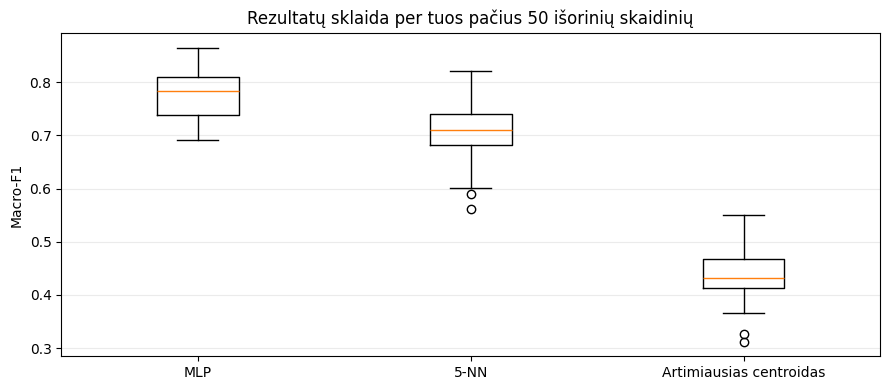

In [3]:
table(data, [method, 'knn', 'centroid'])
comparison_plot(data, [method, 'knn', 'centroid'])

## Klasių metrikos ir painiavos matrica

Kiekvienas objektas teste pasirodo penkis kartus. Čia pateiktos sujungtų išorinių prognozių metrikos.

,Preciziškumas,Jautrumas,F1,Prognozių skaičius
bus,0.936,0.964,0.950,1090.0
opel,0.626,0.549,0.585,1060.0
saab,0.620,0.642,0.631,1085.0
van,0.914,0.968,0.940,995.0


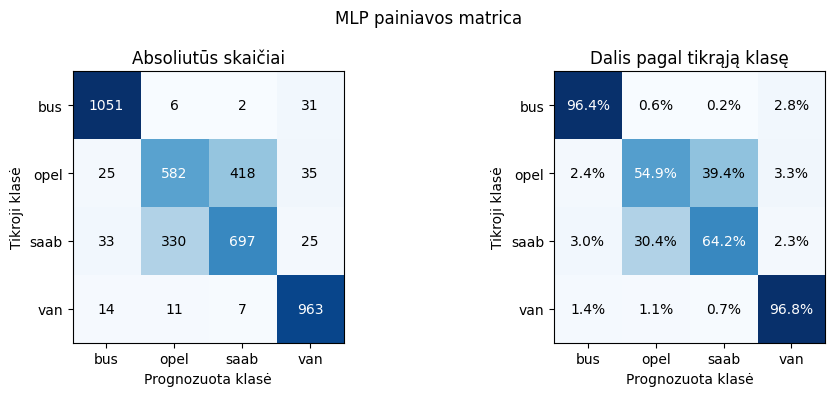

In [4]:
class_analysis(data, method)

## Dešimt klaidų pavyzdžių

Rodomi skirtingi įrašai ir dažniausia jų klaidinga klasė; vienodi dažniai sprendžiami pagal klasių tvarką. Tai klaidų pasikartojimo, ne užtikrintumo reitingas. Pradinių siluetų vaizdų faile nėra.

,Tikroji klasė,Dažniausia klaidinga klasė,Šios klaidos kartai,Visos klaidos iš 5
Įrašo indeksas,,,,
23,bus,van,5,5
29,saab,opel,5,5
32,opel,saab,5,5
58,opel,saab,5,5
75,opel,saab,5,5
77,saab,bus,5,5
91,opel,saab,5,5
113,opel,saab,5,5
142,opel,saab,5,5


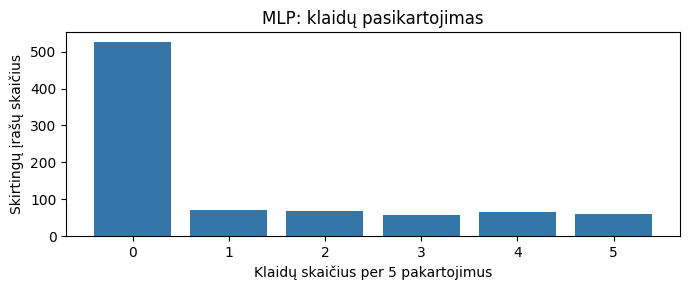

In [5]:
error_examples(data, method)

## Atsparumas triukšmui ir trūkstamiems požymiams

Trikdžiai taikyti tik išoriniam testui: trys triukšmo lygiai, 5 % ir 10 % trūkstamų langelių, po 20 realizacijų. Visi metodai gavo tuos pačius trikdžius. Lentelėje – šis metodas, grafike – ir baseline.

Macro-F1  Balanced accuracy  Macro-F1 kritimas
kind    level                                                
missing 0.05     0.7407             0.7465             0.0344
        0.10     0.7108             0.7165             0.0643
noise   0.05     0.7738             0.7798             0.0013
        0.10     0.7672             0.7733             0.0079
        0.20     0.7398             0.7456             0.0353

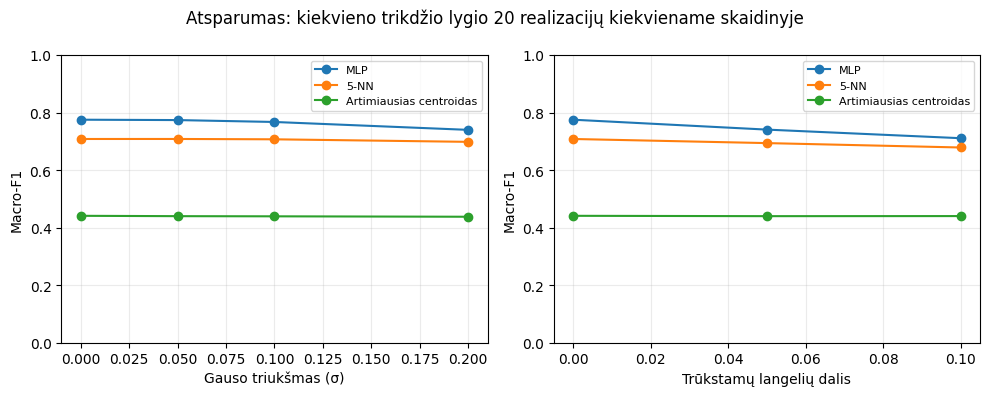

In [6]:
robustness_analysis(data, method)

## Eksperimento abliacija ir požymių jautrumas

Ši užduoties dalis atlikta pagrindiniam **SVM**. MLP ir RBF sąsiuviniuose tai bendro eksperimento kontekstas, ne šių alternatyvų abliacija. Permutacija ir vieno požymio visiškas trūkumas yra atskiri trikdžiai.

,Macro-F1 ± SD,Balanced accuracy ± SD,"Mokymas su paieška, s"
Metodas,,,
SVM RBF,0.842 ± 0.031,0.843 ± 0.030,3.812
Tiesinis SVM,0.794 ± 0.036,0.797 ± 0.036,2.012
SVM be standartizavimo,0.756 ± 0.040,0.765 ± 0.037,5.031


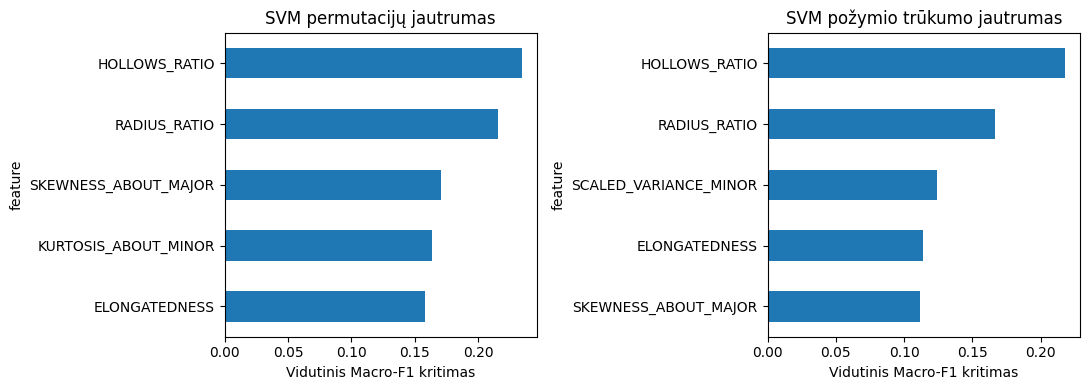

In [7]:
ablations(data)

## Formulė ir konkreti kodo vieta

Paslėpto sluoksnio taisyklė: $h=\max(0,zW+b)$ (ReLU). `src/models.py::EncodedMLP.fit` naudoja `MLPClassifier(activation="relu", solver="adam", early_stopping=True)`. `hidden_layer_sizes` nurodo sluoksnius, `alpha` – reguliarizaciją, `learning_rate_init` – pradinį mokymosi žingsnį. Tekstinės klasės viduje užkoduojamos skaičiais ir prognozuojant atkuriamos.

In [8]:
import inspect
from src.models import build_pipeline, EncodedMLP, RBFNetwork
# Tikras naudojamos realizacijos kodas.
print(inspect.getsource(EncodedMLP.fit))

    def fit(self, X, y):
        # Klasės surikiuojamos; encoded saugo kiekvienos mokymo žymės skaitinį indeksą.
        self.classes_, encoded = np.unique(y, return_inverse=True)
        # ReLU: h=max(0, zW+b). Adam atnaujina svorius; early_stopping stabdo pagal vidinę validaciją.
        self.network_ = MLPClassifier(hidden_layer_sizes=self.hidden_layer_sizes,
                                      alpha=self.alpha, learning_rate_init=self.learning_rate_init,
                                      activation="relu", solver="adam", early_stopping=True,
                                      max_iter=2000, random_state=self.random_state)
        self.network_.fit(X, encoded)
        return self



## Vertinimo protokolas ir ribos

846 įrašai, 18 požymių, keturios klasės. Visiems metodams naudoti tie patys **5 × 10 stratifikuoti išoriniai skaidiniai**. Parametrai parinkti atskira **5 dalių vidine CV** pagal Macro-F1. Medianų pildymas ir standartizavimas išmokti mokymo dalyse. Išorinis testas nenaudotas parinkimui.

**SD** yra skaidinių rezultatų standartinis nuokrypis, ne pasikliautinasis intervalas. Skaidiniai priklausomi. Klasių metrikose ir painiavos matricoje kiekvienas įrašas pasirodo penkis kartus – iš viso 4 230 prognozių vienam modeliui. Klasių metrikos skaičiuotos iš sujungtų prognozių, pagrindinis Macro-F1 – kaip 50 skaidinių vidurkis.

Tinklelių sumažinimas dėl biudžeto aprašytas [plano_patikslinimai.md](plano_patikslinimai.md). Rezultatai galioja mažam keturių modelių rinkiniui; realaus eismo ir naujų fizinių modelių veikimas nepatikrintas.

## Neprivalomas mokymo pakartojimas

Nustatykite `RUN_TRAINING = True` tik norėdami mokyti iš naujo. Tai trunka kelias minutes ir išsaugo atskirą `results/notebook_<metodas>.csv`. Visas eksperimentas: `python run_experiment.py --config configs/main.yaml`.

In [9]:
RUN_TRAINING = False
if RUN_TRAINING:
    from pathlib import Path
    import pandas as pd
    import yaml
    from src.data import load_vehicle
    from run_experiment import make_outer_splits, fit_model, metrics
    cfg = yaml.safe_load(Path('configs/main.yaml').read_text(encoding='utf-8'))
    X, y, metadata = load_vehicle(Path('data'))
    rows = []
    for split, (repeat, fold, train, test) in enumerate(make_outer_splits(X, y, cfg)):
        model, params = fit_model(method, X.iloc[train], y.iloc[train], cfg,
                                  cfg['seed'] + repeat * 100 + fold, jobs=1)
        rows.append({'split': split, 'repeat': repeat, 'fold': fold,
                     **metrics(y.iloc[test], model.predict(X.iloc[test])), 'params': str(params)})
    results = pd.DataFrame(rows)
    results.to_csv(f'results/notebook_{method}.csv', index=False)
    display(results[['macro_f1', 'balanced_accuracy']].agg(['mean', 'std']))
else:
    print('Mokymas nepaleistas. Rodomi pilno išsaugoto eksperimento rezultatai.')


Mokymas nepaleistas. Rodomi pilno išsaugoto eksperimento rezultatai.
